In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/ae_features.csv', parse_dates=['WeekEndingDate'])

# XGBoost uses ALL boards at once — it learns cross-board patterns
mainland_boards = df['BoardName'].unique()
print(f"Boards: {len(mainland_boards)}")
print(f"Total rows: {len(df)}")
print(f"Date range: {df['WeekEndingDate'].min().date()} → {df['WeekEndingDate'].max().date()}")

Boards: 11
Total rows: 6446
Date range: 2015-02-22 → 2026-05-10


In [2]:
# Encode board as a numeric feature
le = LabelEncoder()
df['BoardCode'] = le.fit_transform(df['HBT'])

feature_cols = [
    # Board identity
    'BoardCode', 'SIMDScore', 'IsUrban', 'PopulationK',
    # Calendar
    'WeekOfYear', 'Month', 'FluSeasonFlag', 'WinterFlag', 'ChristmasWeek',
    # COVID
    'CovidEra', 'PostCovidStress', 'CovidPhase', 'VaxRollout',
    # Lag & rolling
    'Lag1_BreachRate', 'Lag2_BreachRate', 'Lag4_BreachRate', 'Lag8_BreachRate',
    'Lag1_Attendances', 'Lag4_Attendances',
    'RollingMean4W', 'RollingMean8W', 'RollingStd4W', 'RollingMax4W',
    'BreachRateDelta',
    # External
    'FluSearchIndex', 'IsSchoolHoliday', 'DaysToNextHoliday',
    'StaffingRatioPer1000', 'StaffingPressureFlag',
    # Attendance pressure
    'AttendancesPer1000',
]

target = 'BreachRate'

# Drop rows with NaN in any feature (first few weeks per board)
model_df = df[feature_cols + [target, 'WeekEndingDate', 'BoardName']].dropna().copy()

print(f"Rows after dropping NaNs: {len(model_df)}")
print(f"Features: {len(feature_cols)}")

# Train/test split — same cutoff as other models
train_xg = model_df[model_df['WeekEndingDate'] < '2023-01-01']
test_xg  = model_df[model_df['WeekEndingDate'] >= '2023-01-01']

X_train = train_xg[feature_cols]
y_train = train_xg[target]
X_test  = test_xg[feature_cols]
y_test  = test_xg[target]

print(f"\nTrain: {len(X_train)} rows across all boards")
print(f"Test:  {len(X_test)} rows across all boards")

Rows after dropping NaNs: 6347
Features: 30

Train: 4422 rows across all boards
Test:  1925 rows across all boards


In [3]:
model_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric='rmse'
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print(f"\nBest iteration: {model_xgb.best_iteration}")

[0]	validation_0-rmse:0.23844
[50]	validation_0-rmse:0.04781
[100]	validation_0-rmse:0.04120
[150]	validation_0-rmse:0.04106
[185]	validation_0-rmse:0.04108

Best iteration: 155


In [4]:
pred_xgb = model_xgb.predict(X_test).clip(0, 1)
actual   = y_test.values

def metrics(actual, predicted, label):
    predicted = np.array(predicted)
    mape = np.mean(np.abs((actual - predicted) / np.clip(actual, 0.01, None))) * 100
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    print(f"\n=== {label} ===")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    return mape, rmse, mae

mape_xg, rmse_xg, mae_xg = metrics(actual, pred_xgb, "XGBoost (all boards)")

print(f"\n--- Leaderboard so far ---")
print(f"  SARIMAX + exog:          MAPE 67.30%")
print(f"  Prophet logistic:        MAPE 28.45%")
print(f"  XGBoost:                 MAPE {mape_xg:.2f}%")


=== XGBoost (all boards) ===
  MAPE : 10.55%
  RMSE : 0.0410
  MAE  : 0.0318

--- Leaderboard so far ---
  SARIMAX + exog:          MAPE 67.30%
  Prophet logistic:        MAPE 28.45%
  XGBoost:                 MAPE 10.55%


In [5]:
# Isolate Forth Valley test rows for apple-to-apple comparison
fv_test = test_xg[test_xg['BoardName'] == 'Forth Valley']
pred_fv = model_xgb.predict(fv_test[feature_cols]).clip(0, 1)

mape_fv, rmse_fv, mae_fv = metrics(
    fv_test[target].values, pred_fv,
    "XGBoost — Forth Valley only"
)


=== XGBoost — Forth Valley only ===
  MAPE : 8.39%
  RMSE : 0.0564
  MAE  : 0.0448


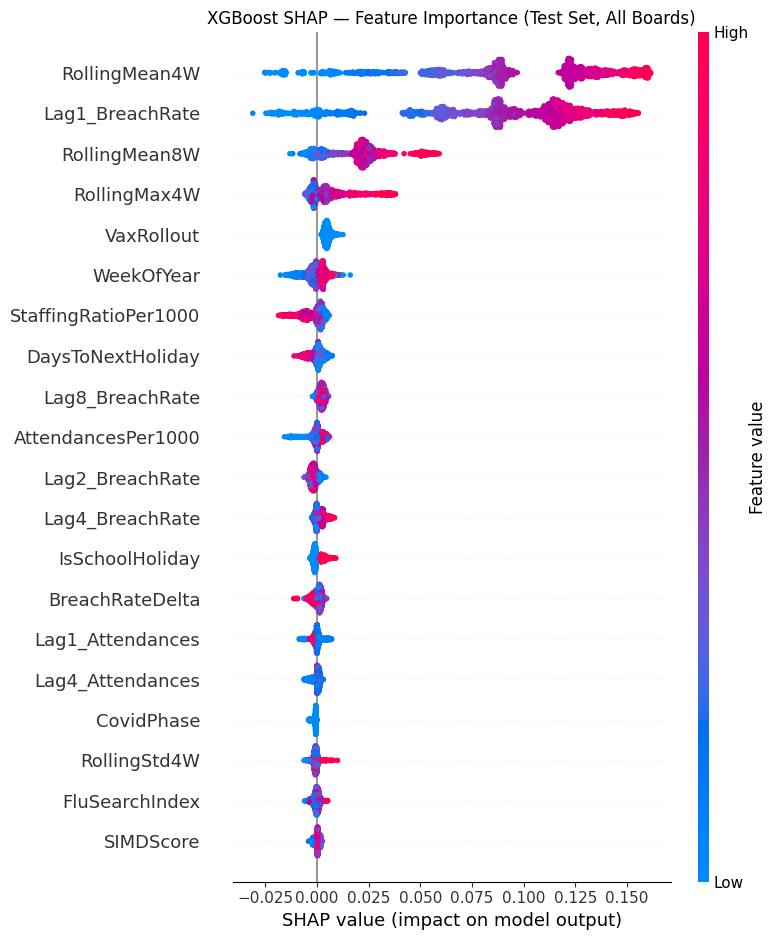

In [6]:
explainer  = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

# Global feature importance — beeswarm plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                  show=False, max_display=20)
plt.title('XGBoost SHAP — Feature Importance (Test Set, All Boards)')
plt.tight_layout()
plt.savefig('../data/processed/xgb_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

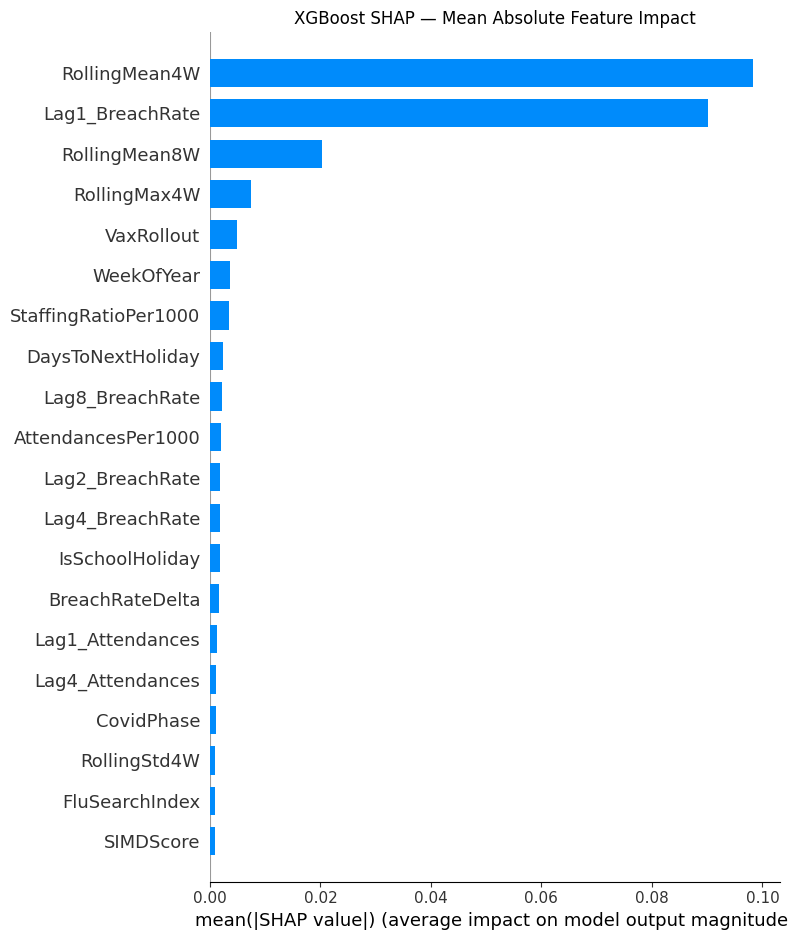

In [7]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                  plot_type='bar', show=False, max_display=20)
plt.title('XGBoost SHAP — Mean Absolute Feature Impact')
plt.tight_layout()
plt.savefig('../data/processed/xgb_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining prediction for week: 2024-10-13
Predicted breach rate: 0.576
Actual breach rate:    0.540


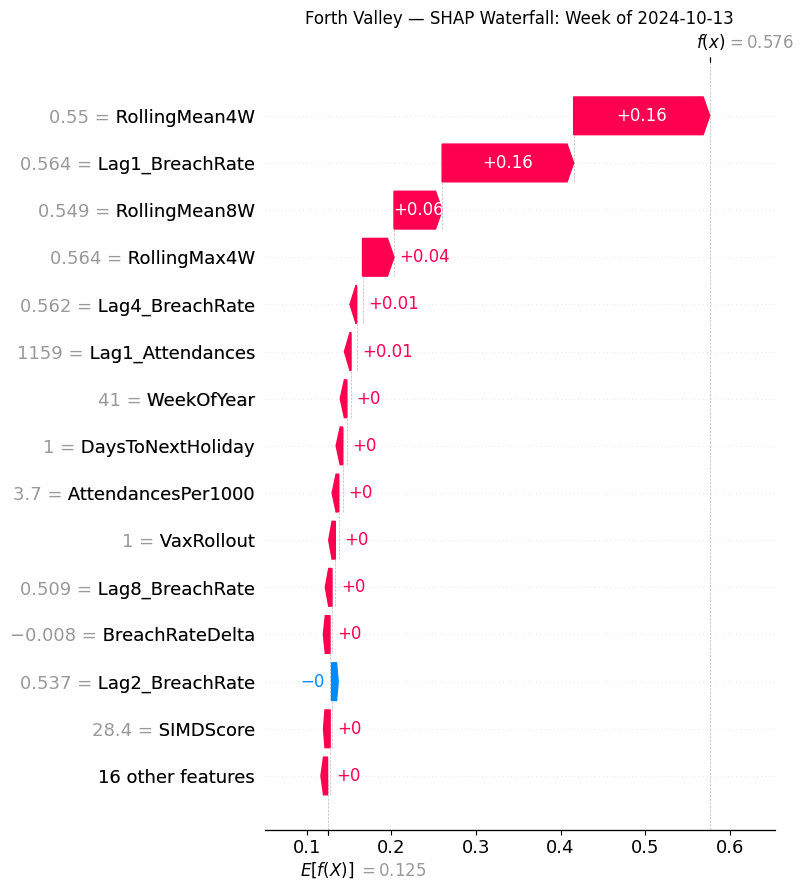

In [8]:
# Pick the highest predicted breach week in Forth Valley test set
fv_test_idx  = test_xg[test_xg['BoardName'] == 'Forth Valley'].index
fv_shap      = shap.TreeExplainer(model_xgb)(X_test.loc[fv_test_idx])

# Find the week with highest predicted breach rate
fv_preds     = model_xgb.predict(X_test.loc[fv_test_idx])
worst_week_i = np.argmax(fv_preds)
worst_week_date = test_xg.loc[fv_test_idx, 'WeekEndingDate'].iloc[worst_week_i]

print(f"Explaining prediction for week: {worst_week_date.date()}")
print(f"Predicted breach rate: {fv_preds[worst_week_i]:.3f}")
print(f"Actual breach rate:    {test_xg.loc[fv_test_idx, 'BreachRate'].iloc[worst_week_i]:.3f}")

plt.figure(figsize=(10, 7))
shap.waterfall_plot(fv_shap[worst_week_i], max_display=15, show=False)
plt.title(f'Forth Valley — SHAP Waterfall: Week of {worst_week_date.date()}')
plt.tight_layout()
plt.savefig('../data/processed/xgb_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

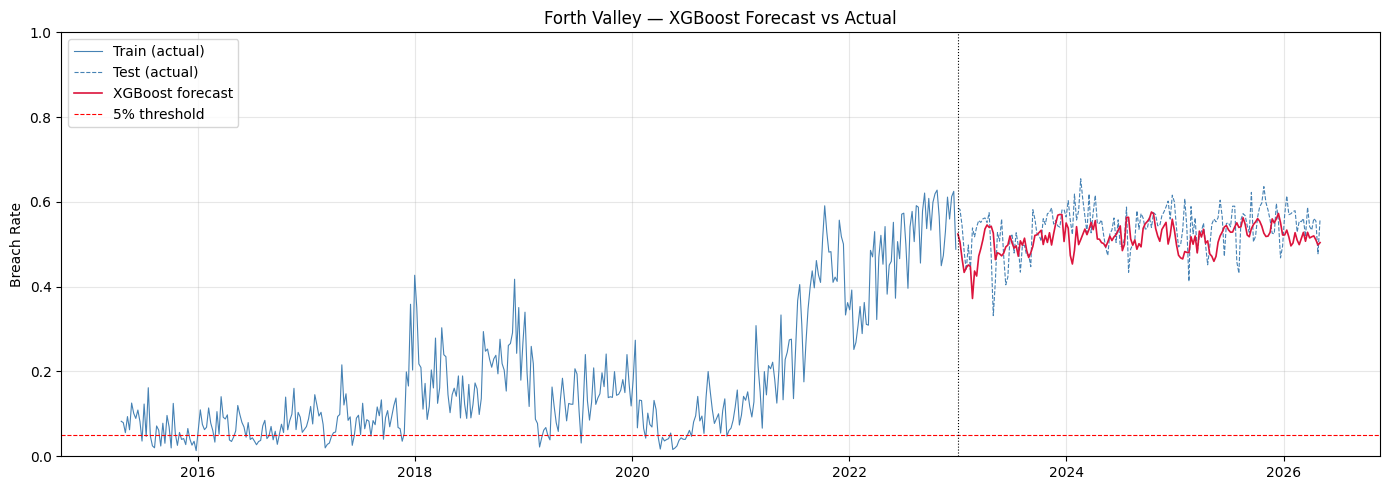

In [9]:
fv_test_plot = test_xg[test_xg['BoardName'] == 'Forth Valley'].copy()
fv_train_plot = train_xg[train_xg['BoardName'] == 'Forth Valley'].copy()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(fv_train_plot['WeekEndingDate'], fv_train_plot['BreachRate'],
        color='steelblue', linewidth=0.8, label='Train (actual)')
ax.plot(fv_test_plot['WeekEndingDate'], fv_test_plot['BreachRate'],
        color='steelblue', linewidth=0.8, linestyle='--', label='Test (actual)')
ax.plot(fv_test_plot['WeekEndingDate'],
        model_xgb.predict(fv_test_plot[feature_cols]).clip(0, 1),
        color='crimson', linewidth=1.2, label='XGBoost forecast')
ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8, label='5% threshold')
ax.axvline(pd.Timestamp('2023-01-01'), color='black', linestyle=':', linewidth=0.8)
ax.set_title('Forth Valley — XGBoost Forecast vs Actual')
ax.set_ylabel('Breach Rate')
ax.set_ylim(0, 1)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/fv_xgboost_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
results = pd.read_csv('../data/processed/model_results.csv')

xgb_results = pd.DataFrame({
    'Model': ['XGBoost All Boards', 'XGBoost Forth Valley'],
    'MAPE':  [10.55, 8.39],
    'RMSE':  [0.0410, 0.0564],
    'MAE':   [0.0318, 0.0448],
    'Board': ['All 11 boards', 'Forth Valley'],
    'Notes': ['Full feature set, 30 features, early stopping at iteration 155',
              'Forth Valley subset — apple-to-apple with SARIMAX/Prophet']
})

results = pd.concat([results, xgb_results], ignore_index=True)
results.to_csv('../data/processed/model_results.csv', index=False)
print(results[['Model', 'MAPE', 'RMSE', 'MAE']].to_string())

                         Model   MAPE    RMSE     MAE
0             SARIMAX Baseline  71.77  0.4319  0.3836
1               SARIMAX + Exog  67.30  0.4061  0.3595
2             Prophet Baseline  66.51  0.3762  0.3541
3               Prophet + Exog  67.74  0.3826  0.3606
4       Prophet Logistic + Cap  28.45  0.1604  0.1487
5   Prophet Logistic + Plateau  28.98  0.1631  0.1515
6           XGBoost All Boards  10.55  0.0410  0.0318
7         XGBoost Forth Valley   8.39  0.0564  0.0448
8           XGBoost All Boards  10.55  0.0410  0.0318
9         XGBoost Forth Valley   8.39  0.0564  0.0448
10          XGBoost All Boards  10.55  0.0410  0.0318
11        XGBoost Forth Valley   8.39  0.0564  0.0448
